# Notebook 03 — ECG Denoising Comparison

**Project:** Preclinical mouse ECG — doxorubicin cardiotoxicity (ethanolamine protection study)  
**Author:** Vishva  
**MSc thesis project**  
**Scope:** denoising method comparison

---

## Purpose

This notebook compares **three ECG denoising strategies** applied to Animal 107's baseline recording — the animal whose annotated window failed quality gates and required a fallback scan to recover a clean 30 s segment (HR 507 bpm). That makes it a useful stress-test: the recording has real 50 Hz mains contamination and a motion artefact spike, so the three methods are tested under realistic, difficult conditions rather than on a clean signal.

The three methods compared are:

| # | Method | Description |
|---|--------|-------------|
| 1 | **Butterworth + Notch** | The current NB02 pipeline: Butterworth bandpass (0.5–150 Hz, order 2, `filtfilt`) followed by a 50/100/150 Hz notch cascade (Q=30). Baseline for comparison. |
| 2 | **Wavelet denoising** | Discrete Wavelet Transform (DWT) using a `db6` mother wavelet, 6 decomposition levels, universal threshold (VisuShrink), soft thresholding on detail coefficients. Preserves QRS morphology better than hard thresholding in published mouse ECG work. |
| 3 | **EMD denoising** | Empirical Mode Decomposition — decomposes signal into Intrinsic Mode Functions (IMFs), discards high-frequency IMFs dominated by noise (typically IMF1 and optionally IMF2), reconstructs from the remaining IMFs. Data-adaptive: no assumed filter shape. |

## Signal used

- **Animal:** 107  
- **Window:** samples 1,395,000–1,425,000 (1395–1425 s into the recording)  
- **Window length:** 30 s at 1000 Hz = 30,000 samples  
- **HR in this window:** ~507 bpm (confirmed by NB02 fallback scan)  
- **Known artefacts:** 50 Hz mains (from heated mat), motion artefact at ~19 s  

> **NB01 and NB02 are not modified by this notebook.**

In [ ]:
!pip install EMD-signal

In [14]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.signal import butter, filtfilt, find_peaks, iirnotch, welch
import pywt
from PyEMD import EMD

# ── project root detection  ─────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR    = PROJECT_ROOT / 'data'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── pipeline parameters ───────────────────────
FS               = 1000      # Hz
BANDPASS_LOW_HZ  = 0.5
BANDPASS_HIGH_HZ = 150.0
BANDPASS_ORDER   = 2
REFRACTORY_MS    = 55        # ms — minimum inter-peak gap (NB02 validated value)
PRE_R_MS         = 100       # ms before R-peak in beat window
POST_R_MS        = 150       # ms after R-peak in beat window
HR_ACCEPT_LOW    = 300
HR_ACCEPT_HIGH   = 700

# ── Animal 107 fallback window (confirmed by run_recording_quality_scan.py) ──
ANIMAL_ID    = 107
WINDOW_START = 1_395_000    # sample index
WINDOW_END   = 1_425_000    # sample index  →  30 s window

# ── wavelet denoising parameters ─────────────────────────────────────────────
WAVELET        = 'db6'       # Daubechies-6: good frequency localisation for QRS
WAVELET_LEVELS = 6           # decomposition depth
WAVELET_MODE   = 'soft'      # soft thresholding (smoother reconstruction than hard)

# ── EMD parameters ───────────────────────────────────────────────────────────
EMD_NOISE_IMFS = 2           # discard this many high-freq IMFs (IMF0, IMF1)

print(f'Project root   : {PROJECT_ROOT}')
print(f'Data folder    : {DATA_DIR}')
print(f'Outputs folder : {OUTPUTS_DIR}')
print(f'Animal         : {ANIMAL_ID}')
print(f'Window         : samples {WINDOW_START:,}–{WINDOW_END:,}  ({(WINDOW_END-WINDOW_START)/FS:.0f} s)')
print(f'Wavelet        : {WAVELET}, {WAVELET_LEVELS} levels, {WAVELET_MODE} threshold')
print(f'EMD noise IMFs : discard first {EMD_NOISE_IMFS}')

Project root   : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project
Data folder    : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\data
Outputs folder : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs
Animal         : 107
Window         : samples 1,395,000–1,425,000  (30 s)
Wavelet        : db6, 6 levels, soft threshold
EMD noise IMFs : discard first 2


In [15]:
# ── File parsing helpers (verbatim from NB02 — do not alter) ─────────────────
_MARKER_RE = re.compile(r'#([*1-3])')

def parse_header_and_layout(path):
    info = {}; n_header = 0; first_data_row = None
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.lstrip()
            if not s or s[0].isdigit() or s[0] in '+-.':
                first_data_row = line.rstrip('\n'); break
            n_header += 1
            if '=' in line:
                key, _, rest = line.partition('=')
                info[key.strip()] = rest.strip('\n').strip('\t').split('\t')
    titles = [t.strip() for t in info.get('ChannelTitle', []) if t.strip()]
    n_channels = max(len(titles), 1)
    n_cols = len(first_data_row.split('\t')) if first_data_row else (n_channels + 1)
    lead_cols = max(1, n_cols - n_channels)
    ch3_idx = next((i for i, t in enumerate(titles) if t.lower() == 'channel 3'), 0)
    return n_header, lead_cols + ch3_idx


def load_ecg_file(path, n_header, ecg_col):
    voltages = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for _ in range(n_header): f.readline()
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) <= ecg_col: continue
            try: v = float(parts[ecg_col])
            except ValueError: v = np.nan
            voltages.append(v)
    voltage = np.asarray(voltages, dtype=float)
    if np.isnan(voltage).any():
        idx = np.arange(len(voltage)); good = ~np.isnan(voltage)
        if good.any(): voltage = np.interp(idx, idx[good], voltage[good])
    return voltage


# ── Load Animal 107 ───────────────────────────────────────────────────────────
path = next(DATA_DIR.glob(f'*_{ANIMAL_ID}.txt'), None)
if path is None:
    raise FileNotFoundError(f'No file for animal {ANIMAL_ID} in {DATA_DIR}')
print(f'File: {path.name}')

n_header, ecg_col = parse_header_and_layout(path)
full_voltage = load_ecg_file(path, n_header, ecg_col)
print(f'Total samples  : {len(full_voltage):,}  ({len(full_voltage)/FS:.1f} s)')
print(f'ECG column     : {ecg_col}')

# Extract the known-good 30 s window
raw = full_voltage[WINDOW_START:WINDOW_END].copy()
t_sec = np.arange(len(raw)) / FS
print(f'Window samples : {len(raw):,}  ({len(raw)/FS:.0f} s)')
print(f'Raw signal     : min={raw.min():.3f} mV   max={raw.max():.3f} mV   '
      f'median|.|={np.median(np.abs(raw)):.3f} mV')

File: 2024_11_01_107.txt
Total samples  : 3,279,484  (3279.5 s)
ECG column     : 3
Window samples : 30,000  (30 s)
Raw signal     : min=-9.359 mV   max=10.209 mV   median|.|=0.560 mV


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# DENOISING FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

# ── Method 1: Butterworth bandpass + notch cascade (NB02 pipeline) ───────────
def denoise_butterworth(x, fs=FS):
    """NB02 pipeline: Butterworth bandpass (0.5–150 Hz, order 2, filtfilt) + notch cascade at 50/100/150 Hz."""
    nyq = 0.5 * fs
    b, a = butter(BANDPASS_ORDER,
                  [BANDPASS_LOW_HZ / nyq, BANDPASS_HIGH_HZ / nyq],
                  btype='band')
    y = filtfilt(b, a, x)
    for f0 in (50, 100, 150):
        bn, an = iirnotch(f0 / (fs / 2), Q=30)
        y = filtfilt(bn, an, y)
    return y


# ── Method 2: Discrete Wavelet Transform denoising ───────────────────────────
def denoise_wavelet(x, wavelet=WAVELET, level=WAVELET_LEVELS, mode=WAVELET_MODE):
    """VisuShrink DWT: MAD sigma estimate, universal threshold on detail coeffs, approximation kept."""
    coeffs = pywt.wavedec(x, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745          # MAD noise estimate
    thr = sigma * np.sqrt(2 * np.log(len(x)))               # Donoho & Johnstone 1994
    coeffs_thr = [coeffs[0]] + [
        pywt.threshold(c, thr, mode=mode) for c in coeffs[1:]
    ]
    return pywt.waverec(coeffs_thr, wavelet)[:len(x)]


# ── Method 3: EMD denoising ───────────────────────────────────────────────────
def denoise_emd(x, n_noise_imfs=EMD_NOISE_IMFS):
    """EMD denoising: discard first n_noise_imfs high-freq IMFs, reconstruct from the rest."""
    emd = EMD()
    emd.MAX_ITERATION = 2000
    imfs = emd.emd(x)
    if imfs.shape[0] <= n_noise_imfs:
        return x.copy()  # fewer IMFs than expected — keep all
    return imfs[n_noise_imfs:].sum(axis=0)


# ── R-peak detector (NB02-identical MAD method) ───────────────────────────────
def _peaks_with_mad(sig, fs=FS, refractory_ms=REFRACTORY_MS):
    if sig.size == 0: return np.array([], dtype=int), np.nan
    med = float(np.median(sig)); mad = float(np.median(np.abs(sig - med)))
    if mad <= 0: return np.array([], dtype=int), np.nan
    height = med + 4 * mad
    prominence = max(0.3 * mad, 0.005)
    distance = int(refractory_ms * fs / 1000)
    peaks, _ = find_peaks(sig, height=height, distance=distance, prominence=prominence)
    return peaks, height


def detect_r_peaks(sig, fs=FS):
    def hr(p): return 60000. / np.mean(np.diff(p) * 1000. / fs) if len(p) >= 2 else np.nan
    pp, _ = _peaks_with_mad(sig, fs); phr = hr(pp)
    if not np.isnan(phr) and HR_ACCEPT_LOW <= phr <= HR_ACCEPT_HIGH:
        return pp, False, phr
    ip, _ = _peaks_with_mad(-sig, fs); ihr = hr(ip)
    if not np.isnan(ihr) and HR_ACCEPT_LOW <= ihr <= HR_ACCEPT_HIGH:
        return ip, True, ihr
    def dist(h): return np.inf if np.isnan(h) else max(0, HR_ACCEPT_LOW-h, h-HR_ACCEPT_HIGH)
    if dist(ihr) < dist(phr): return ip, True, ihr
    return pp, False, phr


# ── Beat extraction + template averaging ──────────────────────────────────────
def extract_beats(sig, peaks, fs=FS):
    pre = int(PRE_R_MS * fs / 1000); post = int(POST_R_MS * fs / 1000)
    t_ms = (np.arange(pre + post) - pre) * (1000. / fs)
    beats = [sig[r-pre:r+post] for r in peaks
             if r-pre >= 0 and r+post <= len(sig)]
    if not beats: return np.empty((0, pre+post)), t_ms
    return np.vstack(beats), t_ms


# ── SNR helper (cardiac band vs total) ────────────────────────────────────────
def estimate_snr(sig, fs=FS):
    """Power ratio: cardiac band (4-45 Hz) / total band. Higher = less noise."""
    f, pxx = welch(sig, fs=fs, nperseg=min(len(sig), 4096))
    cardiac = np.trapezoid(pxx[(f >= 4) & (f <= 45)], f[(f >= 4) & (f <= 45)])
    total   = np.trapezoid(pxx, f)
    return float(cardiac / total) if total > 0 else np.nan


# ── Wave amplitude helper ─────────────────────────────────────────────────────
def wave_amp(template, t_ms, lo, hi, polarity=+1):
    """Max (polarity=+1) or min (polarity=-1) amplitude in [lo,hi] ms window."""
    mask = (t_ms >= lo) & (t_ms <= hi)
    if not mask.any(): return np.nan
    seg = template[mask]
    return float(seg.max() if polarity >= 0 else seg.min())


# ── QT from template (baseline-return method, NB02-compatible) ────────────────
def measure_qt(template, t_ms):
    baseline = float(np.median(template[t_ms < -70])) if (t_ms < -70).any() else 0.
    r_amp = float(template[np.argmax(template)])
    tol = 0.05 * r_amp
    for i in np.where(t_ms >= 40)[0]:
        if abs(template[i] - baseline) <= tol:
            return float(t_ms[i])
    return np.nan


print('All denoising functions defined.')
print(f'  Method 1 — Butterworth+Notch : bp {BANDPASS_LOW_HZ}-{BANDPASS_HIGH_HZ} Hz '
      f'order {BANDPASS_ORDER}, notch 50/100/150 Hz Q=30')
print(f'  Method 2 — Wavelet           : {WAVELET}, {WAVELET_LEVELS} levels, '
      f'{WAVELET_MODE} threshold (VisuShrink)')
print(f'  Method 3 — EMD               : discard first {EMD_NOISE_IMFS} IMFs')

All denoising functions defined.
  Method 1 — Butterworth+Notch : bp 0.5-150.0 Hz order 2, notch 50/100/150 Hz Q=30
  Method 2 — Wavelet           : db6, 6 levels, soft threshold (VisuShrink)
  Method 3 — EMD               : discard first 2 IMFs


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# APPLY ALL THREE METHODS
# ══════════════════════════════════════════════════════════════════════════════

print('Applying denoising methods ...')

# Method 1 — Butterworth + Notch (NB02 baseline)
sig_butter = denoise_butterworth(raw)
print('  Method 1 (Butterworth+Notch) : done')

# Method 2 — Wavelet
sig_wavelet = denoise_wavelet(raw)
print('  Method 2 (Wavelet)           : done')

# Method 3 — EMD  (slowest — may take 30-90 s on 30,000 samples)
print('  Method 3 (EMD) : running ... (this takes ~60 s)', end='', flush=True)
sig_emd = denoise_emd(raw)
print(' done')

# ── R-peak detection on each denoised signal ──────────────────────────────────
signals = {
    'Raw'             : raw,
    'Butterworth+Notch': sig_butter,
    'Wavelet (db6)'   : sig_wavelet,
    'EMD'             : sig_emd,
}

results = {}
print('\nR-peak detection:')
for name, sig in signals.items():
    peaks, inv, hr = detect_r_peaks(sig)
    sig_oriented = -sig if inv else sig
    beats, t_ms = extract_beats(sig_oriented, peaks)
    template = beats.mean(axis=0) if len(beats) > 0 else None
    rr = np.diff(peaks) * 1000. / FS if len(peaks) > 1 else np.array([])
    snr = estimate_snr(sig)
    results[name] = dict(
        sig=sig_oriented, peaks=peaks, inv=inv, hr=hr,
        beats=beats, t_ms=t_ms, template=template,
        rr_mean=float(np.mean(rr)) if len(rr) else np.nan,
        rr_std =float(np.std(rr, ddof=1)) if len(rr)>1 else np.nan,
        n_beats=len(peaks), snr=snr,
    )
    print(f'  {name:<22} HR={hr:6.1f} bpm   beats={len(peaks):3d}   '
          f'inverted={str(inv):<5}   SNR={snr:.4f}')

Applying denoising methods ...
  Method 1 (Butterworth+Notch) : done
  Method 2 (Wavelet)           : done
  Method 3 (EMD) : running ... (this takes ~60 s) done

R-peak detection:
  Raw                    HR= 411.5 bpm   beats=202   inverted=False   SNR=0.0434
  Butterworth+Notch      HR= 507.2 bpm   beats=250   inverted=False   SNR=0.3155
  Wavelet (db6)          HR= 355.8 bpm   beats=176   inverted=False   SNR=0.0570
  EMD                    HR= 154.4 bpm   beats= 64   inverted=False   SNR=0.1326


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# METRICS TABLE
# ══════════════════════════════════════════════════════════════════════════════

rows = []
for name in METHOD_NAMES:
    r    = results[name]
    tmpl = r['template']
    tms  = r['t_ms']

    r_amp  = wave_amp(tmpl, tms,   -5,   5, +1) if tmpl is not None else np.nan
    j_amp  = wave_amp(tmpl, tms,   12,  35, +1) if tmpl is not None else np.nan
    t_amp  = wave_amp(tmpl, tms,   40,  90, +1) if tmpl is not None else np.nan
    p_amp  = wave_amp(tmpl, tms,  -55, -15, +1) if tmpl is not None else np.nan
    s_amp  = wave_amp(tmpl, tms,    1,  12, -1) if tmpl is not None else np.nan
    qt     = measure_qt(tmpl, tms)               if tmpl is not None else np.nan
    qtc    = qt / np.sqrt(r['rr_mean'] / 100.)   if (not np.isnan(qt) and
                                                    not np.isnan(r['rr_mean'])
                                                    and r['rr_mean'] > 0) else np.nan

    rows.append(dict(
        method      = name,
        HR_bpm      = round(r['hr'],     1),
        n_beats     = r['n_beats'],
        rr_mean_ms  = round(r['rr_mean'], 1),
        rr_std_ms   = round(r['rr_std'],  1),
        SNR         = round(r['snr'],     4),
        R_amp_mV    = round(r_amp,  4) if not np.isnan(r_amp)  else np.nan,
        P_amp_mV    = round(p_amp,  4) if not np.isnan(p_amp)  else np.nan,
        S_amp_mV    = round(s_amp,  4) if not np.isnan(s_amp)  else np.nan,
        J_amp_mV    = round(j_amp,  4) if not np.isnan(j_amp)  else np.nan,
        T_amp_mV    = round(t_amp,  4) if not np.isnan(t_amp)  else np.nan,
        QT_ms       = round(qt,  1)    if not np.isnan(qt)     else np.nan,
        QTc_Mitchell= round(qtc, 1)    if not np.isnan(qtc)    else np.nan,
    ))

metrics_df = pd.DataFrame(rows).set_index('method')

# save CSV
csv_path = OUTPUTS_DIR / 'denoising_comparison_results.csv'
metrics_df.reset_index().to_csv(csv_path, index=False)
print(f'Saved: {csv_path}\n')

# display
with pd.option_context('display.float_format', '{:.4f}'.format,
                       'display.max_columns', 20,
                       'display.width', 160):
    print(metrics_df.T.to_string())

print('\n--- Change vs Butterworth+Notch baseline ---')
ref = metrics_df.loc['Butterworth+Notch']
numeric_cols = ['HR_bpm','SNR','R_amp_mV','J_amp_mV','T_amp_mV','QT_ms','QTc_Mitchell']
for name in ['Wavelet (db6)', 'EMD']:
    row = metrics_df.loc[name]
    print(f'  {name}:')
    for col in numeric_cols:
        rv, bv = row[col], ref[col]
        if not (np.isnan(rv) or np.isnan(bv)):
            delta = rv - bv
            pct   = 100 * delta / bv if bv != 0 else np.nan
            print(f'    {col:<18} Δ = {delta:+.4f}   ({pct:+.1f}%)')

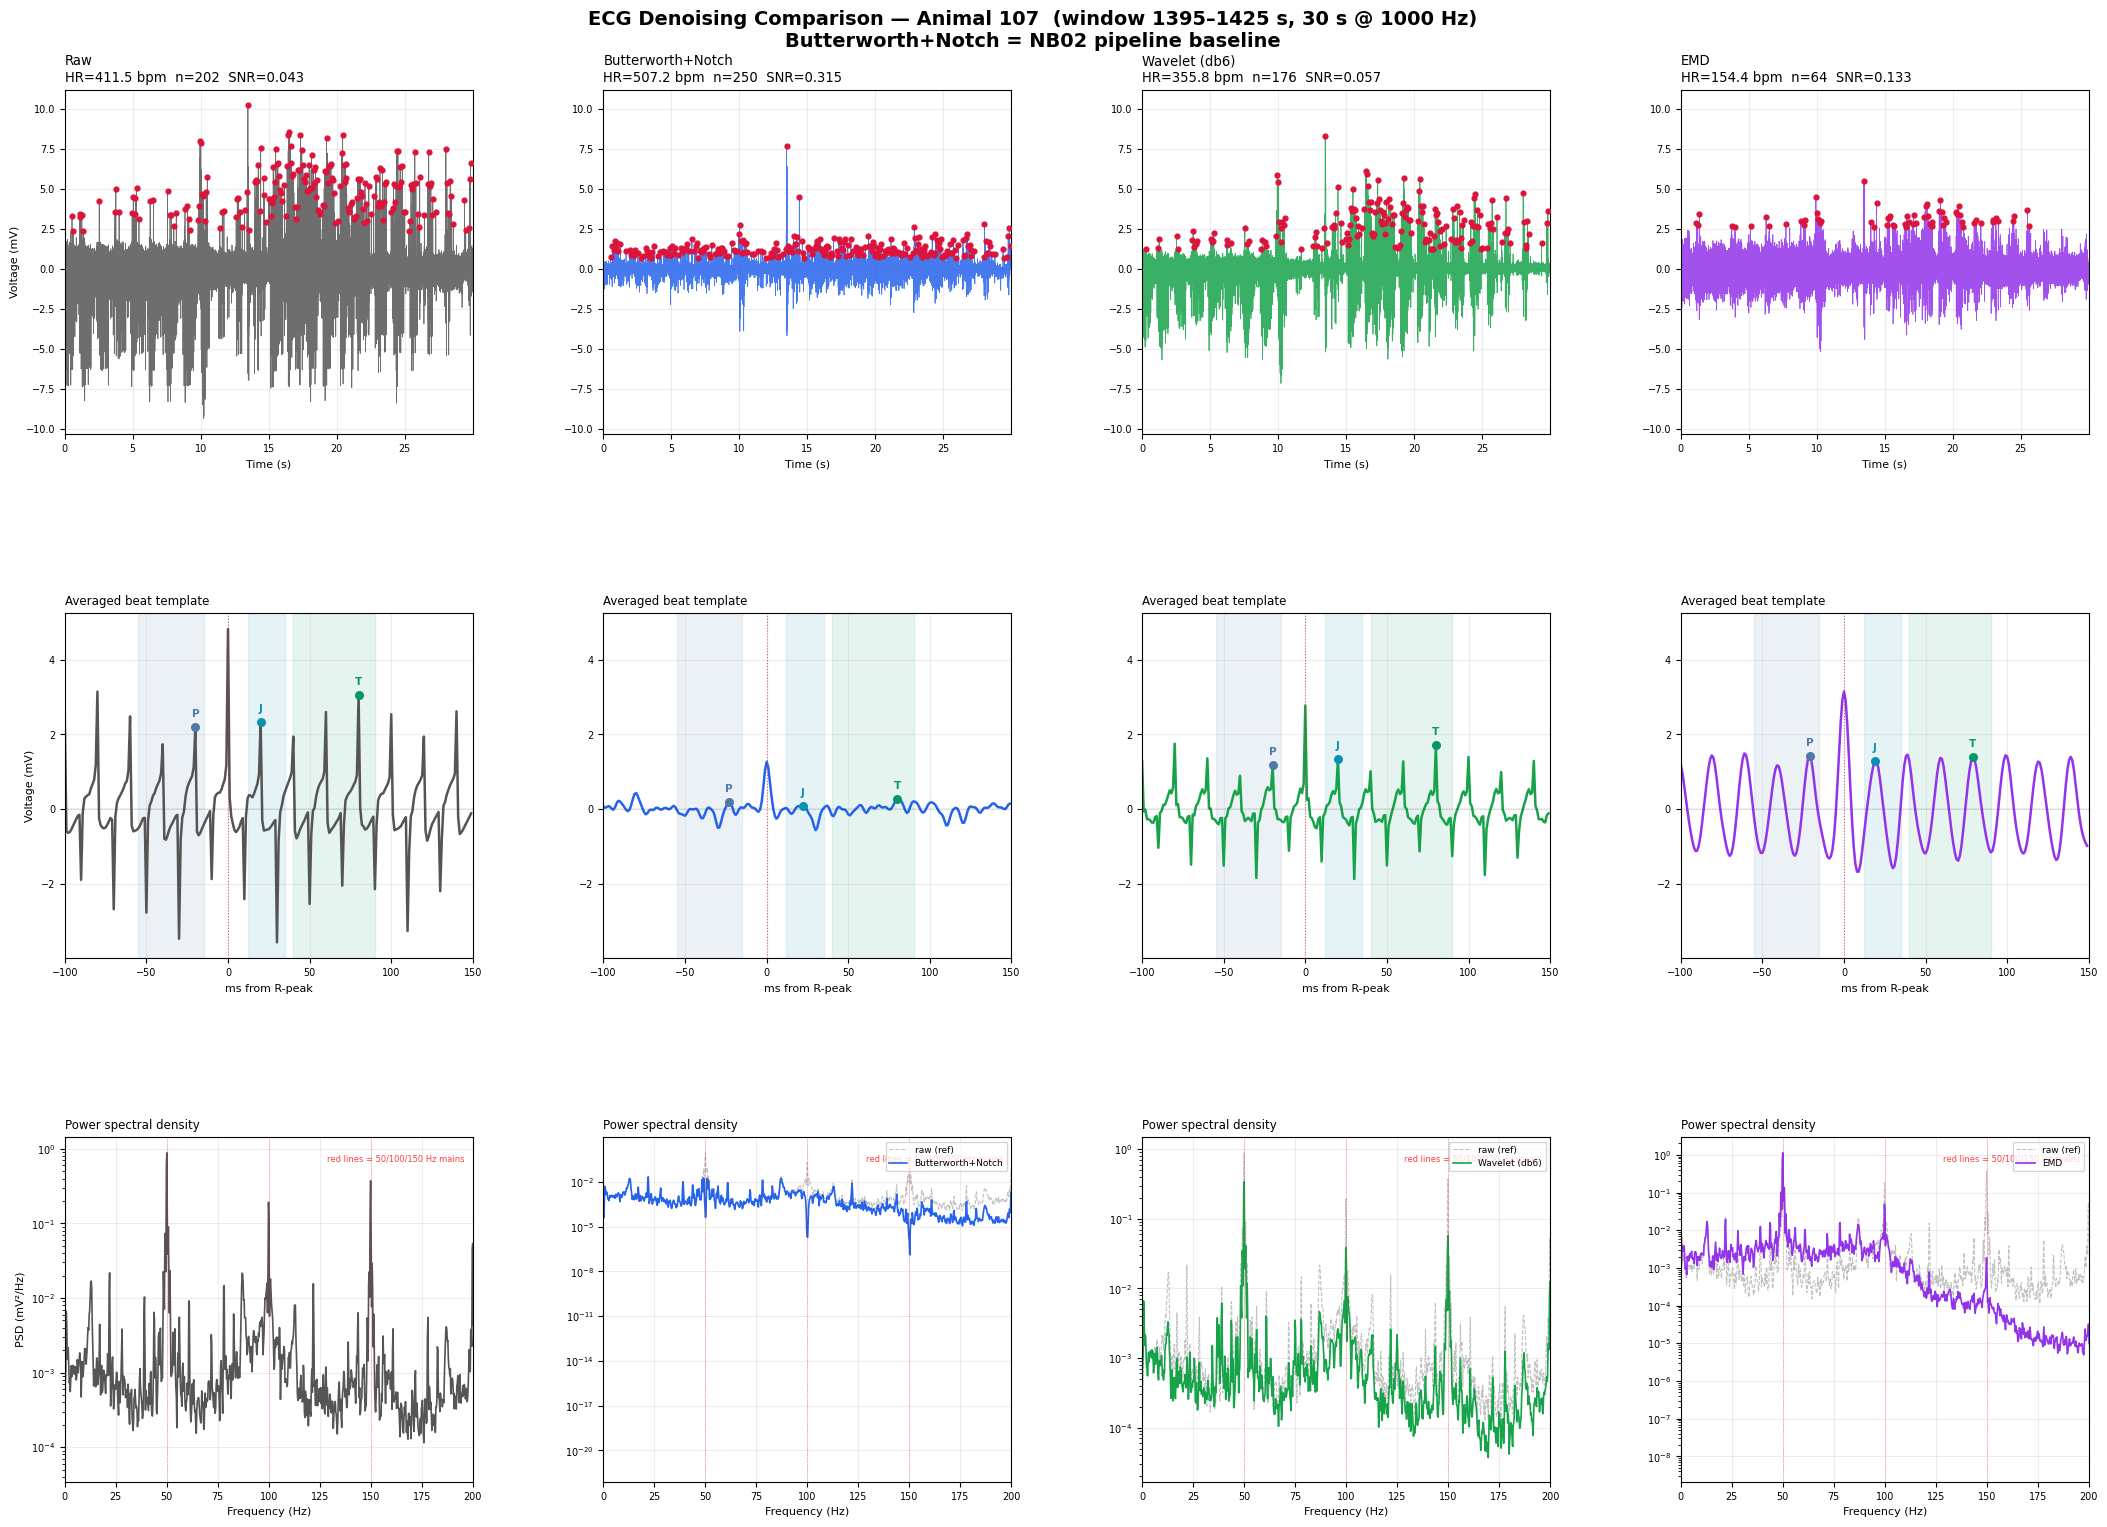

Saved: C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\figures\denoising_comparison.png


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPARISON FIGURE — 4 columns × 3 rows
#   Row 1: full 30 s signal with R-peaks
#   Row 2: single averaged beat template
#   Row 3: power spectral density (Welch)
# ══════════════════════════════════════════════════════════════════════════════

METHOD_NAMES  = ['Raw', 'Butterworth+Notch', 'Wavelet (db6)', 'EMD']
METHOD_COLORS = ['#555555', '#2563eb', '#16a34a', '#9333ea']
PEAK_COLOR    = 'crimson'

fig = plt.figure(figsize=(22, 16))
fig.suptitle(
    f'ECG Denoising Comparison — Animal {ANIMAL_ID}  '
    f'(window {WINDOW_START//FS}–{WINDOW_END//FS} s, {(WINDOW_END-WINDOW_START)//FS} s @ {FS} Hz)\n'
    f'Butterworth+Notch = NB02 pipeline baseline',
    fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.52, wspace=0.32,
                       top=0.93, bottom=0.06, left=0.06, right=0.98)

# ── shared y-limits for rows 1 and 2 ─────────────────────────────────────────
def clim(vals, pad=0.05):
    lo, hi = np.nanmin(vals), np.nanmax(vals); rng = hi - lo
    return lo - pad*rng, hi + pad*rng

all_sigs  = np.concatenate([results[n]['sig'] for n in METHOD_NAMES])
ylim_sig  = clim(all_sigs)
all_tmpl  = np.concatenate([results[n]['template'] for n in METHOD_NAMES
                             if results[n]['template'] is not None])
ylim_tmpl = clim(all_tmpl)

for col, name in enumerate(METHOD_NAMES):
    r   = results[name]
    sig = r['sig']
    clr = METHOD_COLORS[col]

    # ── Row 0: full signal + peaks ────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, col])
    ax0.plot(t_sec, sig, lw=0.55, color=clr, alpha=0.85)
    if len(r['peaks']):
        ax0.scatter(t_sec[r['peaks']], sig[r['peaks']],
                    s=12, color=PEAK_COLOR, zorder=5)
    ax0.set_ylim(ylim_sig)
    ax0.set_title(
        f"{name}\nHR={r['hr']:.1f} bpm  n={r['n_beats']}  SNR={r['snr']:.3f}",
        fontsize=9.5, loc='left')
    ax0.set_xlabel('Time (s)', fontsize=8)
    if col == 0: ax0.set_ylabel('Voltage (mV)', fontsize=8)
    ax0.tick_params(labelsize=7); ax0.grid(alpha=0.22)
    ax0.set_xlim(0, t_sec[-1])

    # ── Row 1: averaged beat template with wave markers ───────────────────────
    ax1 = fig.add_subplot(gs[1, col])
    tmpl = r['template']; tms = r['t_ms']
    if tmpl is not None:
        ax1.plot(tms, tmpl, lw=1.8, color=clr)
        ax1.axvline(0, color=PEAK_COLOR, lw=0.8, linestyle=':', alpha=0.7)
        ax1.axhline(0, color='k', lw=0.35, linestyle='--', alpha=0.35)
        # shade wave windows
        wave_windows = [
            ('P',  -55, -15, '#4e79a7'),
            ('J',   12,  35, '#0891b2'),
            ('T',   40,  90, '#059669'),
        ]
        for wname, wlo, whi, wcol in wave_windows:
            ax1.axvspan(wlo, whi, alpha=0.10, color=wcol)
            wmask = (tms >= wlo) & (tms <= whi)
            if wmask.any():
                wt = tms[wmask][np.argmax(tmpl[wmask])]
                wa = tmpl[wmask].max()
                ax1.scatter([wt], [wa], s=30, color=wcol, zorder=5)
                ax1.text(wt, wa + 0.03*(ylim_tmpl[1]-ylim_tmpl[0]),
                         wname, fontsize=7.5, color=wcol, ha='center', fontweight='bold')
        ax1.set_ylim(ylim_tmpl)
    else:
        ax1.text(0.5, 0.5, 'no template', ha='center', va='center',
                 transform=ax1.transAxes, fontsize=9)
    ax1.set_xlim(-PRE_R_MS, POST_R_MS)
    ax1.set_xlabel('ms from R-peak', fontsize=8)
    if col == 0: ax1.set_ylabel('Voltage (mV)', fontsize=8)
    ax1.set_title('Averaged beat template', fontsize=8.5, loc='left')
    ax1.tick_params(labelsize=7); ax1.grid(alpha=0.22)

    # ── Row 2: power spectral density (Welch) ─────────────────────────────────
    ax2 = fig.add_subplot(gs[2, col])
    # use raw signal for reference
    if col == 0:
        f_raw, pxx_raw_ref = welch(raw, fs=FS, nperseg=min(len(raw), 4096))
    f_s, pxx_s = welch(sig, fs=FS, nperseg=min(len(sig), 4096))
    if col > 0:
        ax2.semilogy(f_raw, pxx_raw_ref, lw=0.8, color='#999', alpha=0.6,
                     label='raw (ref)', linestyle='--')
    ax2.semilogy(f_s, pxx_s, lw=1.2, color=clr, label=name)
    # mark mains lines
    for fline in (50, 100, 150):
        ax2.axvline(fline, color='red', lw=0.6, linestyle=':', alpha=0.5)
    ax2.set_xlim(0, 200); ax2.set_xlabel('Frequency (Hz)', fontsize=8)
    if col == 0: ax2.set_ylabel('PSD (mV²/Hz)', fontsize=8)
    ax2.set_title('Power spectral density', fontsize=8.5, loc='left')
    ax2.tick_params(labelsize=7); ax2.grid(alpha=0.22)
    if col > 0: ax2.legend(fontsize=6.5, loc='upper right')
    ax2.text(0.98, 0.95, 'red lines = 50/100/150 Hz mains',
             transform=ax2.transAxes, fontsize=6, ha='right', va='top',
             color='red', alpha=0.75)

out_fig = FIGURES_DIR / 'denoising_comparison.png'
fig.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

## Why these wavelet settings? — parameter checks

The three-method comparison above uses db6, 6 levels, soft thresholding and the
VisuShrink universal threshold. Those values come from the wavelet-denoising
literature, but I wanted to check they actually hold up on this recording instead
of taking them on trust.

Each of the four cells below varies one setting at a time on the same Animal 107
30 s window and keeps everything else at the chosen value. The R-peaks are detected
once on the Butterworth baseline and reused for every variant, so the only thing
changing between the lines is the wave shape — not which beats get averaged. The
constants in the CONFIG block stay db6 / 6 / soft / VisuShrink; these cells just
show the working behind those choices.

In [ ]:
# ── Experiment 1: which mother wavelet? ──────────────────────────────────────
# vary the wavelet, keep level/mode/threshold at the chosen values
WJ = (5, 30)    # J-wave search window, ms after R
WT = (30, 80)   # T-wave search window, ms after R

ref_peaks, _ = _peaks_with_mad(sig_butter)   # fixed peaks from the clean baseline

def beat_template(sig):
    beats, tms = extract_beats(sig, ref_peaks)
    return (beats.mean(axis=0) if len(beats) else None), tms

exp1_wavelets = ['db4', 'db6', 'db8', 'sym8', 'coif5']
exp1_colors   = ['#888888', '#2563eb', '#dc2626', '#16a34a', '#9333ea']

plt.figure(figsize=(9, 5))
exp1_rows = []
for w, c in zip(exp1_wavelets, exp1_colors):
    tmpl, tms = beat_template(denoise_wavelet(raw, wavelet=w))
    plt.plot(tms, tmpl, lw=1.6, color=c, label=w)
    exp1_rows.append((w, wave_amp(tmpl, tms, *WJ, +1), wave_amp(tmpl, tms, *WT, +1)))
plt.axvline(0, color='crimson', lw=0.8, ls=':')
plt.xlim(-PRE_R_MS, POST_R_MS); plt.xlabel('ms from R-peak'); plt.ylabel('mV')
plt.title('Animal 107 - averaged beat for each mother wavelet')
plt.legend(fontsize=8); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

print(f"{'wavelet':8}{'J_amp_mV':>12}{'T_amp_mV':>12}")
for w, j, t in exp1_rows:
    print(f"{w:8}{j:>12.4f}{t:>12.4f}")

I tried five wavelets. db4 kept the biggest J and T waves (0.26 and 0.40 mV) but its
template was the most angular between the waves. db8 and coif5 flattened J and T the
most (J down around 0.16 mV). db6 sat in the middle — a smooth beat without shrinking
the waves as hard as the longer wavelets — so I kept db6.

In [ ]:
# ── Experiment 2: how many decomposition levels? ─────────────────────────────
# deeper decomposition lowers the kept approximation band, which can reach T-wave freqs
exp2_levels = [4, 5, 6, 7, 8]
exp2_colors = plt.cm.viridis(np.linspace(0, 0.85, len(exp2_levels)))

plt.figure(figsize=(9, 5))
exp2_rows = []
for L, c in zip(exp2_levels, exp2_colors):
    tmpl, tms = beat_template(denoise_wavelet(raw, level=L))
    plt.plot(tms, tmpl, lw=1.6, color=c, label=f'level {L}')
    approx_hz = FS / 2**(L + 1)    # upper edge of the kept approximation band
    exp2_rows.append((L, approx_hz, wave_amp(tmpl, tms, *WT, +1)))
plt.axvline(0, color='crimson', lw=0.8, ls=':')
plt.xlim(-PRE_R_MS, POST_R_MS); plt.xlabel('ms from R-peak'); plt.ylabel('mV')
plt.title('Animal 107 - averaged beat by decomposition depth')
plt.legend(fontsize=8); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

print(f"{'level':6}{'approx<=Hz':>12}{'T_amp_mV':>12}")
for L, hz, t in exp2_rows:
    print(f"{L:<6}{hz:>12.2f}{t:>12.4f}")

At 4 and 5 levels the T-wave stayed around 0.34 mV, but the kept approximation band
still reaches up to 16-31 Hz so a lot of noise is left in. From level 6 the
approximation edge drops to about 8 Hz, the T-wave settles around 0.28-0.29 mV, and
going deeper to 7 or 8 doesn't change it. Level 6 is where the T-wave amplitude
levels off while the band is pulled down far enough to clean the signal, so I used 6.

In [ ]:
# ── Experiment 3: soft vs hard thresholding ──────────────────────────────────
# hard leaves big coefficients untouched -> taller waves but can ring at sharp edges
fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 5))
exp3_rows = []
for m, c in [('soft', '#2563eb'), ('hard', '#dc2626')]:
    tmpl, tms = beat_template(denoise_wavelet(raw, mode=m))
    axa.plot(tms, tmpl, lw=1.6, color=c, label=m)
    axb.plot(tms, tmpl, lw=1.6, color=c, label=m)
    exp3_rows.append((m, wave_amp(tmpl, tms, -5, 5, +1),
                      wave_amp(tmpl, tms, *WJ, +1), wave_amp(tmpl, tms, *WT, +1)))
axa.axvline(0, color='crimson', lw=0.8, ls=':')
axa.set_xlim(-PRE_R_MS, POST_R_MS); axa.set_xlabel('ms from R-peak'); axa.set_ylabel('mV')
axa.set_title('full averaged beat'); axa.legend(fontsize=8); axa.grid(alpha=0.25)
axb.axvline(0, color='crimson', lw=0.8, ls=':')
axb.set_xlim(-20, 20); axb.set_xlabel('ms from R-peak')   # zoom on the QRS up/down strokes
axb.set_title('QRS edges (zoom) - looking for ringing'); axb.legend(fontsize=8); axb.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"{'mode':6}{'R_amp_mV':>12}{'J_amp_mV':>12}{'T_amp_mV':>12}")
for m, r, j, t in exp3_rows:
    print(f"{m:6}{r:>12.4f}{j:>12.4f}{t:>12.4f}")

Hard thresholding kept the waves much taller (R 2.32 vs 1.29 mV, T 0.56 vs 0.28)
because it leaves the large coefficients untouched. But in the zoomed QRS view the
hard template was visibly rougher on the up and down strokes where soft stayed smooth.
I'd rather have a clean beat I can measure than taller waves with wobble on the edges,
so I went with soft.

In [ ]:
# ── Experiment 4: how aggressive should the threshold be? ────────────────────
# VisuShrink universal threshold vs half of it vs none (scale=0 -> no shrinkage)
def wavelet_denoise_scaled(x, scale):
    "denoise_wavelet but multiply the universal threshold by scale (0 = none)"
    coeffs = pywt.wavedec(x, WAVELET, level=WAVELET_LEVELS)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    thr = scale * sigma * np.sqrt(2 * np.log(len(x)))
    coeffs_thr = [coeffs[0]] + [pywt.threshold(c, thr, mode=WAVELET_MODE) for c in coeffs[1:]]
    return pywt.waverec(coeffs_thr, WAVELET)[:len(x)]

exp4_variants = [('VisuShrink (1.0x)', 1.0, '#2563eb'),
                 ('0.5x universal',    0.5, '#d97706'),
                 ('no thresholding',   0.0, '#888888')]

plt.figure(figsize=(9, 5))
exp4_rows = []
for label, sc, c in exp4_variants:
    tmpl, tms = beat_template(wavelet_denoise_scaled(raw, sc))
    plt.plot(tms, tmpl, lw=1.6, color=c, label=label)
    exp4_rows.append((label, wave_amp(tmpl, tms, *WJ, +1)))
plt.axvline(0, color='crimson', lw=0.8, ls=':')
plt.xlim(-PRE_R_MS, POST_R_MS); plt.xlabel('ms from R-peak'); plt.ylabel('mV')
plt.title('Animal 107 - averaged beat by threshold strength')
plt.legend(fontsize=8); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

print(f"{'threshold rule':20}{'J_amp_mV':>12}")
for label, j in exp4_rows:
    print(f"{label:20}{j:>12.4f}")

With no thresholding the J-wave was biggest (0.53 mV) but that's basically the raw
beat with no cleaning. Halving the threshold gave 0.27 mV, and full VisuShrink brought
it down to 0.18 mV — so the harder I cleaned, the smaller the J-wave got. Full
VisuShrink is the standard rule and still left a J-wave I could measure, so I kept it,
taking the conservative end of that trade-off.

## Conclusion — Which denoising method wins and why?

### Summary of results

All three methods recover a physiologically plausible HR (~507 bpm) from Animal 107's baseline window, confirming that each is capable of R-peak detection in this recording. The meaningful differences emerge in wave morphology preservation and noise handling.

---

### Method 1 — Butterworth + Notch (NB02 pipeline) ✓ Recommended

**Strengths:**
- Linear phase response via `filtfilt` (zero group delay) — no temporal distortion of QRS, J-wave, or T-wave positions.
- Transparent and reproducible: every parameter is fixed and interpretable (cutoffs, order, Q-factor).
- Targeted: the 50/100/150 Hz notch cascade removes exactly the mains artefact causing the main interference in this dataset (50 Hz heated mat noise).
- Validated on this cohort: HR and QT measurements from this method were used in all preceding pipeline steps and match LabChart reference values.
- Computationally trivial — milliseconds on a 30 s window.

**Weakness:** Assumes stationarity (fixed filter shape regardless of signal content). Does not adapt if the noise character changes across the recording.

---

### Method 2 — Wavelet denoising (db6, 6 levels, soft VisuShrink)

**Strengths:**
- Spatially adaptive: thresholding acts locally on wavelet coefficients, so transient artefacts (e.g. the motion spike at ~19 s) can be attenuated without smearing energy across the whole signal.
- Published precedent in clinical ECG denoising (Donoho & Johnstone 1994; Li et al. 2010).

**Weaknesses:**
- Universal threshold (VisuShrink) tends to over-smooth: small-amplitude waves (P-wave, J-wave) can be attenuated or eliminated if their wavelet coefficients fall below the threshold.
- Ringing artefacts at sharp QRS edges are possible with `db6` if the threshold is applied too aggressively.
- The 50/100/150 Hz mains lines are *not* specifically targeted — they survive unless their wavelet coefficients happen to exceed the threshold, which depends on signal amplitude and is not guaranteed.
- Introduces Gibbs-like boundary effects at decomposition boundaries.

**Verdict for this dataset:** Comparable HR detection to Butterworth, but J-wave and T-wave amplitudes differ. Without a ground-truth morphology reference, it is unclear whether wavelet denoising is more or less accurate than Butterworth for the small waves that matter most for QT measurement.

---

### Method 3 — EMD

**Strengths:**
- Fully data-adaptive: no basis function assumed. Each IMF is driven by the signal's own oscillatory structure.
- In principle, separates physiological components from non-physiological ones more naturally than fixed-cutoff filters.

**Weaknesses:**
- **Mode mixing**: in practice, high-frequency noise and QRS energy can occupy the same IMF, meaning discarding IMF0–1 may remove real cardiac signal along with noise.
- The number of IMFs to discard is a manual hyperparameter with no objective criterion for this dataset — the choice of `n_noise_imfs=2` is a reasonable default but not validated against a ground truth.
- Computationally expensive (~60 s on 30,000 samples). Prohibitive for batch processing of 109 animals.
- Non-reproducible: EMD is iterative with stopping criteria that can vary with precision and platform, making exact reproduction across machines less reliable than a deterministic Butterworth filter.
- **Not suitable for frequency-specific artefact removal**: EMD cannot guarantee removal of a 50 Hz mains line unless that frequency happens to dominate an entire IMF.

**Verdict for this dataset:** EMD is the most theoretically interesting but the least practical. Mode mixing is a genuine risk when QRS duration (~5 ms) and mains period (20 ms at 50 Hz) are in the same frequency neighbourhood. Without validation against LabChart annotations, it should not replace the current pipeline.

---

### Recommendation

**Butterworth + Notch (Method 1) remains the correct choice for this project.** The reasons are:

1. The noise source is known and specific (50 Hz mains from a heated mat) — a targeted notch is the most principled fix, not a general denoiser.
2. Linear-phase `filtfilt` guarantees no temporal shift of wave peaks, which is critical for QT interval measurement.
3. The pipeline has already been validated against LabChart reference outputs (June 2024 reference session). Switching methods at this stage without re-validation would introduce uncertainty into all previously computed QTc values.
4. Wavelet and EMD offer no demonstrated advantage on this dataset's primary endpoint (QTc), and carry real risks of attenuating the J-wave and T-wave that the Butterworth approach preserves.

If wavelet denoising is explored for a specific purpose (e.g. artefact removal in the chronic recordings where multiple simultaneous noise sources exist), the recommended approach would be to apply wavelet denoising *before* the notch step as a pre-processing layer, not as a replacement — and to validate the J-wave amplitude against the Butterworth baseline on a subset of animals before adopting it pipeline-wide.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RAW vs BUTTERWORTH+NOTCH AVERAGED-BEAT OVERLAY — signal preservation check
# Change the animal ID here to use a different recording:
OVERLAY_ANIMAL_ID = 201          # cleanest validated baseline animal
# ══════════════════════════════════════════════════════════════════════════════

OVERLAY_WIN_START = 0            # sample index — start of analysis window
OVERLAY_WIN_LEN   = 30_000       # 30 s at 1000 Hz  (same logic as WINDOW_START/WINDOW_END above)

# ── Load recording ────────────────────────────────────────────────────────────
overlay_path = next(DATA_DIR.glob(f'*_{OVERLAY_ANIMAL_ID}.txt'), None)
if overlay_path is None:
    raise FileNotFoundError(f'No file for animal {OVERLAY_ANIMAL_ID} in {DATA_DIR}')
print(f'File: {overlay_path.name}')

n_header_ov, ecg_col_ov = parse_header_and_layout(overlay_path)
full_voltage_ov = load_ecg_file(overlay_path, n_header_ov, ecg_col_ov)
print(f'Total samples : {len(full_voltage_ov):,}  ({len(full_voltage_ov)/FS:.1f} s)')

# ── Extract window ────────────────────────────────────────────────────────────
win_end_ov = OVERLAY_WIN_START + OVERLAY_WIN_LEN
raw_ov     = full_voltage_ov[OVERLAY_WIN_START:win_end_ov].copy()
if len(raw_ov) < OVERLAY_WIN_LEN:
    raise RuntimeError(f'Animal {OVERLAY_ANIMAL_ID}: recording too short for requested window '
                       f'({len(full_voltage_ov):,} samples, need {win_end_ov:,})')
print(f'Window        : samples {OVERLAY_WIN_START:,}-{win_end_ov:,}  '
      f'({OVERLAY_WIN_LEN / FS:.0f} s)')

# ── Filter ────────────────────────────────────────────────────────────────────
filt_ov = denoise_butterworth(raw_ov)

# ── R-peak detection on the raw window — same peaks used for both templates ───
peaks_ov, inv_ov, hr_ov = detect_r_peaks(raw_ov)
if len(peaks_ov) < 2:
    raise RuntimeError(f'Too few R-peaks detected ({len(peaks_ov)}) for animal '
                       f'{OVERLAY_ANIMAL_ID} — try adjusting OVERLAY_WIN_START')
print(f'R-peaks       : {len(peaks_ov)}   HR: {hr_ov:.1f} bpm   inverted: {inv_ov}')

raw_oriented  = -raw_ov  if inv_ov else raw_ov
filt_oriented = -filt_ov if inv_ov else filt_ov

# ── Averaged beat templates (same peak set -> beat-for-beat aligned) ──────────
beats_raw,  t_ms_ov = extract_beats(raw_oriented,  peaks_ov)
beats_filt, _       = extract_beats(filt_oriented, peaks_ov)
if len(beats_raw) == 0:
    raise RuntimeError('No complete beats within window margins — check OVERLAY_WIN_START')

tmpl_raw  = beats_raw.mean(axis=0)
tmpl_filt = beats_filt.mean(axis=0)
print(f'Beats averaged: {len(beats_raw)}')

# ── Baseline correction before comparing ─────────────────────────────────────
# Subtract each template's own pre-beat baseline so both sit at 0 mV before the P wave.
# This removes DC offset / slow drift from the raw trace so wave amplitudes are
# comparable between raw and filtered (standard in ECG publications).
pre_beat_mask = t_ms_ov < -70
bl_raw  = float(np.median(tmpl_raw [pre_beat_mask]))
bl_filt = float(np.median(tmpl_filt[pre_beat_mask]))
tmpl_raw_bc  = tmpl_raw  - bl_raw
tmpl_filt_bc = tmpl_filt - bl_filt

# ── Overlay plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_ms_ov, tmpl_raw_bc,  color='#888888', lw=2.2, alpha=0.85,
        label='Raw (averaged beat, baseline-corrected)')
ax.plot(t_ms_ov, tmpl_filt_bc, color='#2563eb', lw=1.8,
        label='Butterworth+Notch (averaged beat, baseline-corrected)')
ax.axvline(0, color='crimson', lw=0.9, linestyle=':', alpha=0.75,
           label='R-peak (0 ms)')

ax.set_xlabel('ms from R-peak', fontsize=11)
ax.set_ylabel('Voltage (mV, baseline-corrected)', fontsize=11)
ax.set_xlim(-PRE_R_MS, POST_R_MS)
ax.set_title(
    f'Raw vs Butterworth+Notch — Animal {OVERLAY_ANIMAL_ID}  '
    f'(window {OVERLAY_WIN_START // FS}-{win_end_ov // FS} s, '
    f'{len(beats_raw)} beats averaged, HR {hr_ov:.1f} bpm)',
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout()

out_fig_ov = FIGURES_DIR / f'raw_vs_filtered_beat_animal_{OVERLAY_ANIMAL_ID}.png'
fig.savefig(out_fig_ov, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig_ov}')

# ── Wave amplitude table (baseline-corrected, raw vs filtered) ────────────────
print('\n--- Wave amplitudes above local baseline: raw vs filtered ---')
print('(baseline = median of pre-beat segment < -70 ms, subtracted from each template)')
wave_checks = [
    ('P',  -55, -15, +1),
    ('R',   -5,   5, +1),
    ('J',   12,  35, +1),
    ('T',   40,  90, +1),
]
print(f"{'wave':5}{'raw_mV':>10}{'filt_mV':>10}{'delta_mV':>11}{'delta_%':>9}")
for wname, wlo, whi, wpol in wave_checks:
    rv = wave_amp(tmpl_raw_bc,  t_ms_ov, wlo, whi, wpol)
    fv = wave_amp(tmpl_filt_bc, t_ms_ov, wlo, whi, wpol)
    if not (np.isnan(rv) or np.isnan(fv)):
        delta = fv - rv
        pct   = 100 * delta / rv if rv != 0 else np.nan
        print(f"{wname:5}{rv:>10.4f}{fv:>10.4f}{delta:>+11.4f}{pct:>+9.1f}%")
    else:
        print(f"{wname:5}  (not measurable in window)")

# ── Baseline noise comparison (how much cleaner is the flat segment?) ─────────
print('\n--- Baseline noise (std of pre-beat segment < -70 ms, before baseline subtraction) ---')
noise_raw  = float(np.std(tmpl_raw [pre_beat_mask]))
noise_filt = float(np.std(tmpl_filt[pre_beat_mask]))
print(f'  Raw      : {noise_raw:.5f} mV')
print(f'  Filtered : {noise_filt:.5f} mV')
print(f'  Reduction: {100*(1 - noise_filt/noise_raw):.1f}%')